# GenAI Training: Prompt Engineering with LangChain
## Brew & Bliss Coffee Shop — Customer Review Analysis System

This notebook demonstrates **6 key prompt engineering techniques** using LangChain.  
All examples share a single consistent scenario: analysing customer reviews for **"Brew & Bliss Coffee Shop"**.

### Topics Covered
| # | Technique | Core Idea |
|---|-----------|-----------|
| 1 | Basic Prompting | Direct instruction → structured output |
| 2 | Zero-Shot Prompting | Task described only in words, no examples |
| 3 | Few-Shot Prompting | Guide the model with 2-3 examples |
| 4 | Chain of Thought | Force step-by-step reasoning |
| 5 | Tree of Thoughts | Explore multiple reasoning branches |
| 6 | Question Answering | Ground answers in a custom knowledge base |

> **Prerequisites:** Python 3.9+, an OpenAI API key (or any LangChain-compatible LLM key)


## Setup & Installation
Run the cell below once to install all required packages.

In [18]:
# Run once to install dependencies
!pip install langchain langchain-openai langchain-classic langchain-community langchain-ollama python-dotenv matplotlib seaborn pandas --quiet


In [1]:
from dotenv import load_dotenv
import os
load_dotenv() # Loads variables from .env

True

## Shared Configuration & Dataset
All six sections reuse the **same five customer reviews** and the **same LLM instance** so you can compare results fairly.

In [2]:
import os, re
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate, FewShotPromptTemplate
from langchain_classic.chains import LLMChain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from langchain_ollama import ChatOllama

# ── API key ──────────────────────────────────────────────────────────────
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")   # <-- replace

# ── LLM (swap model name to use GPT-4o, Claude, etc.) ────────────────────
#llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)
llm = ChatOllama(model="gemma3:4b")

# ── Brew & Bliss customer reviews (used throughout the notebook) ──────────
reviews = [
    "The coffee is absolutely amazing and the staff are so friendly! "
    "Best cappuccino in town. Will definitely come back.",          # positive

    "Waited 20 minutes for my order. The latte was lukewarm and "
    "overpriced for the quality. Very disappointing.",              # negative

    "Nice ambiance but the WiFi was slow. "
    "The pastries were fresh and delicious though!",               # mixed

    "The barista recommended their seasonal blend — it was perfect. "
    "Great customer service overall.",                             # positive

    "Terrible experience. My order was wrong twice and the manager "
    "was rude when I complained.",                                 # very negative
]

print("Setup complete!")
print(f"Dataset: {len(reviews)} customer reviews loaded for Brew & Bliss Coffee Shop")


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Setup complete!
Dataset: 5 customer reviews loaded for Brew & Bliss Coffee Shop


---
## 1. Basic Prompting

**What is it?**  
Basic prompting is the simplest way to talk to an LLM. You write a clear instruction (the *prompt*) and the model responds. No special structure, no examples — just a natural-language instruction with one or more placeholder variables.

**LangChain building blocks used**
- `PromptTemplate` — a reusable template with `{variable}` placeholders  
- `LLMChain` — wires the prompt to the LLM and returns the output

**Use-case here**  
We ask the model to read a Brew & Bliss customer review and return a structured mini-report: a one-sentence summary, the main positive point, the main negative point, and a star rating out of 5.


In [28]:
# ── 1a. Define the prompt template ──────────────────────────────────────
basic_prompt = PromptTemplate(
    input_variables=["review"],
    template="""
You are a helpful assistant for Brew & Bliss Coffee Shop.
Analyse the following customer review and provide:
  1. A one-sentence summary
  2. Main positive point (write "None" if absent)
  3. Main negative point (write "None" if absent)
  4. Overall rating: X/5

Customer Review: {review}

Analysis:
"""
)

# ── 1b. Build the chain ──────────────────────────────────────────────────
basic_chain = LLMChain(llm=llm, prompt=basic_prompt)

# ── 1c. Run against the first review ────────────────────────────────────
result = basic_chain.invoke({"review": reviews[0]})
print("Review :", reviews[0])
print("-" * 60)
print("Analysis\n", result["text"])

Review : The coffee is absolutely amazing and the staff are so friendly! Best cappuccino in town. Will definitely come back.
------------------------------------------------------------
Analysis
 Okay, here’s the analysis of the customer review for Brew & Bliss Coffee Shop:

1.  **One-sentence summary:** This customer had a fantastic experience, praising the exceptional coffee and welcoming staff.
2.  **Main positive point:** The coffee is absolutely amazing and the best cappuccino in town.
3.  **Main negative point:** None
4.  **Overall rating:** 5/5 


Review 1 → 5.0/5
Review 2 → 2.0/5
Review 3 → 3.0/5
Review 4 → 5.0/5
Review 5 → 1.0/5


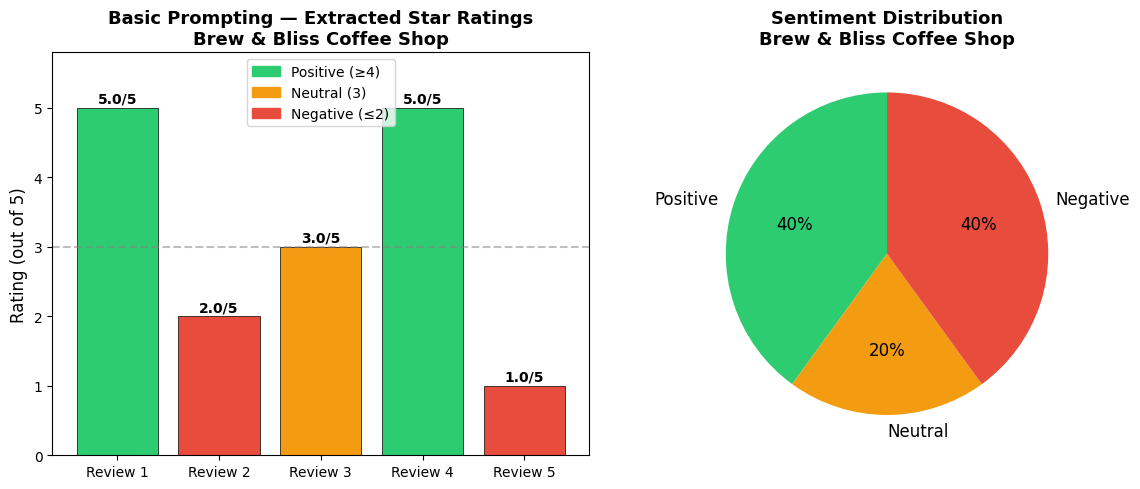

In [29]:
# ── 1d. Analyse all 5 reviews and visualise the ratings ─────────────────

def extract_rating(text):
    """Pull the numeric rating from the LLM response."""
    m = re.search(r"(\d(?:\.\d)?)\s*/\s*5", text)
    return float(m.group(1)) if m else 3.0

labels, ratings = [], []
for i, review in enumerate(reviews):
    resp = basic_chain.invoke({"review": review})
    r = extract_rating(resp["text"])
    ratings.append(r)
    labels.append(f"Review {i+1}")
    print(f"Review {i+1} → {r}/5")

# Bar chart + pie chart side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bar_colors = ["#2ecc71" if r >= 4 else "#e74c3c" if r <= 2 else "#f39c12" for r in ratings]
bars = ax1.bar(labels, ratings, color=bar_colors, edgecolor="black", linewidth=0.5)
ax1.set_ylim(0, 5.8)
ax1.set_ylabel("Rating (out of 5)", fontsize=12)
ax1.set_title("Basic Prompting — Extracted Star Ratings\nBrew & Bliss Coffee Shop", fontsize=13, fontweight="bold")
ax1.axhline(3, color="grey", linestyle="--", alpha=0.5, label="Neutral (3/5)")
for bar, r in zip(bars, ratings):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.07,
             f"{r}/5", ha="center", fontweight="bold")
legend_patches = [
    mpatches.Patch(color="#2ecc71", label="Positive (≥4)"),
    mpatches.Patch(color="#f39c12", label="Neutral (3)"),
    mpatches.Patch(color="#e74c3c", label="Negative (≤2)"),
]
ax1.legend(handles=legend_patches)

sentiment_counts = {
    "Positive": sum(1 for r in ratings if r >= 4),
    "Neutral":  sum(1 for r in ratings if r == 3),
    "Negative": sum(1 for r in ratings if r <= 2),
}
nz = {k: v for k, v in sentiment_counts.items() if v > 0}
ax2.pie(nz.values(), labels=nz.keys(),
        colors=["#2ecc71", "#f39c12", "#e74c3c"][:len(nz)],
        autopct="%1.0f%%", startangle=90, textprops={"fontsize": 12})
ax2.set_title("Sentiment Distribution\nBrew & Bliss Coffee Shop", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("basic_prompting.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 2. Zero-Shot Prompting

**What is it?**  
Zero-shot prompting asks the model to perform a task using *only* a description — **no examples** are provided. The model relies entirely on knowledge it acquired during pre-training to interpret the instruction.

**Why it works**  
Modern LLMs (GPT-3.5+, Claude 3, etc.) have been trained on vast corpora that include many classification, summarisation, and reasoning tasks, so they can generalise to new problems from a description alone.

**Use-case here**  
We classify each Brew & Bliss review into one or more business categories — **SERVICE · QUALITY · ATMOSPHERE · VALUE** — without showing the model any labelled examples.


In [30]:
# ── 2a. Zero-shot classification prompt ─────────────────────────────────
zeroshot_prompt = PromptTemplate(
    input_variables=["review"],
    template="""
Classify the coffee-shop review below into one or more categories:
  SERVICE   — staff behaviour, wait times, customer service
  QUALITY   — food/drink taste, temperature, freshness
  ATMOSPHERE — ambiance, cleanliness, WiFi, comfort
  VALUE     — pricing, portions, value for money

Reply with ONLY the category name(s) in uppercase, comma-separated.

Review: {review}
Categories:
"""
)

zeroshot_chain = LLMChain(llm=llm, prompt=zeroshot_prompt)

# ── 2b. Classify all reviews ─────────────────────────────────────────────
categories_list = []
print("Zero-Shot Classification\n" + "="*60)
for i, review in enumerate(reviews):
    result = zeroshot_chain.invoke({"review": review})
    cat = result["text"].strip()
    categories_list.append(cat)
    print(f"Review {i+1}: {review[:65]}...")
    print(f"  --> {cat}\n")


Zero-Shot Classification
Review 1: The coffee is absolutely amazing and the staff are so friendly! B...
  --> QUALITY, SERVICE, ATMOSPHERE

Review 2: Waited 20 minutes for my order. The latte was lukewarm and overpr...
  --> SERVICE, QUALITY, VALUE

Review 3: Nice ambiance but the WiFi was slow. The pastries were fresh and ...
  --> ATMOSPHERE, QUALITY

Review 4: The barista recommended their seasonal blend — it was perfect. Gr...
  --> QUALITY, SERVICE

Review 5: Terrible experience. My order was wrong twice and the manager was...
  --> SERVICE, VALUE



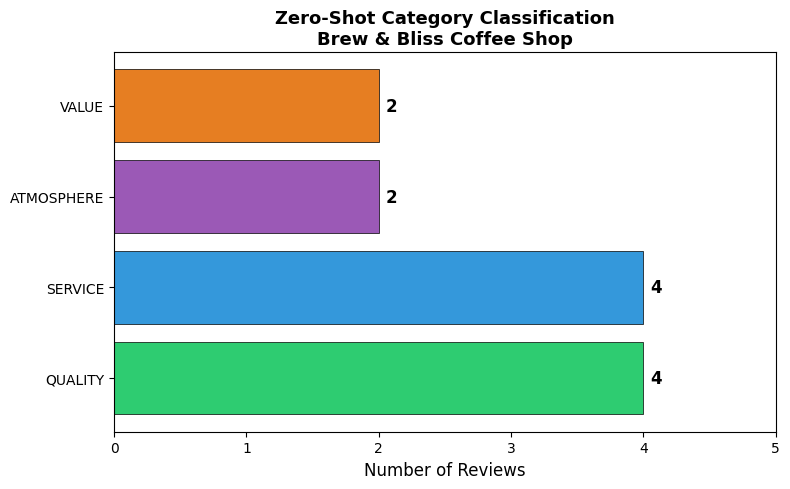

In [31]:
# ── 2c. Visualise category frequency ────────────────────────────────────
from collections import Counter

VALID = {"SERVICE", "QUALITY", "ATMOSPHERE", "VALUE"}
flat = [c.strip() for row in categories_list for c in row.split(",") if c.strip() in VALID]
cat_counts = Counter(flat)

cat_colors = {"SERVICE": "#3498db", "QUALITY": "#2ecc71",
              "ATMOSPHERE": "#9b59b6", "VALUE": "#e67e22"}

fig, ax = plt.subplots(figsize=(8, 5))
cats   = list(cat_counts.keys())
counts = list(cat_counts.values())
colors = [cat_colors.get(c, "#95a5a6") for c in cats]
bars = ax.barh(cats, counts, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Reviews", fontsize=12)
ax.set_title("Zero-Shot Category Classification\nBrew & Bliss Coffee Shop", fontsize=13, fontweight="bold")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(cnt), va="center", fontsize=12, fontweight="bold")
ax.set_xlim(0, max(counts) + 1)
plt.tight_layout()
plt.savefig("zeroshot_classification.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 3. Few-Shot Prompting

**What is it?**  
Few-shot prompting plants **2–5 labelled examples** inside the prompt before the real question. The examples teach the model the exact output style and format expected, making results more predictable and on-brand.

**LangChain building blocks used**
- `FewShotPromptTemplate` — combines an example list, a formatter template, and a suffix for the real question  
- `PromptTemplate` (as the `example_prompt`) — formats each individual example

**Use-case here**  
We show the model two carefully crafted management responses, then ask it to write a similar response for the remaining reviews. The examples teach tone, length, and empathy style.


In [32]:
# ── 3a. Define the few-shot examples ────────────────────────────────────
examples = [
    {
        "review":   "The coffee is amazing and staff are very friendly!",
        "response": "Dear valued guest, thank you so much for your wonderful "
                    "feedback! We are thrilled to hear that you enjoyed our coffee "
                    "and that our team made your visit special. "
                    "We look forward to welcoming you back to Brew & Bliss soon!"
    },
    {
        "review":   "My order took too long and the drink was cold when it arrived.",
        "response": "Dear valued guest, we sincerely apologise for the delay and the "
                    "quality issue you experienced. This is not the standard we hold "
                    "ourselves to at Brew & Bliss. Please visit us again and mention "
                    "this review for a complimentary drink on us. Thank you for bringing "
                    "this to our attention."
    }
]

# ── 3b. Build the FewShotPromptTemplate ─────────────────────────────────
example_formatter = PromptTemplate(
    input_variables=["review", "response"],
    template="Customer Review: {review}\nManagement Response: {response}"
)

fewshot_prompt = FewShotPromptTemplate(
    examples=examples,
    example_prompt=example_formatter,
    prefix=(
        "You are the manager of Brew & Bliss Coffee Shop.\n"
        "Write a professional, empathetic response to the customer review below.\n"
        "Follow the style shown in the examples.\n"
    ),
    suffix="\nCustomer Review: {review}\nManagement Response:",
    input_variables=["review"]
)

fewshot_chain = LLMChain(llm=llm, prompt=fewshot_prompt)

# ── 3c. Generate responses for two unseen reviews ────────────────────────
print("Few-Shot Management Response Generation\n" + "="*60)
for review in [reviews[2], reviews[4]]:   # mixed + very negative
    result = fewshot_chain.invoke({"review": review})
    print(f"\nCustomer Review:\n  {review}")
    print(f"\nManagement Response:\n  {result['text'].strip()}")
    print("-"*60)


Few-Shot Management Response Generation

Customer Review:
  Nice ambiance but the WiFi was slow. The pastries were fresh and delicious though!

Management Response:
  Dear valued guest, thank you so much for taking the time to share your feedback! We’re so glad you appreciated the nice ambiance and that our pastries were fresh and delicious – we truly value your opinion. We’re also very sorry to hear about the slow WiFi; we’re currently looking into improving our network speed. We hope you’ll return to Brew & Bliss and experience a smoother connection. 

Thank you again for your honest review!
------------------------------------------------------------

Customer Review:
  Terrible experience. My order was wrong twice and the manager was rude when I complained.

Management Response:
  Dear valued guest,

We are so incredibly sorry to hear about your truly disappointing experience at Brew & Bliss. To have your order incorrect twice and to encounter a rude interaction with our manager is

Target review: Waited 20 minutes for my order. The latte was lukewarm and overpriced for the quality. Very disappointing.

--- ZERO-SHOT ---
Okay, here are a few options for a professional management response, ranging from more formal to slightly warmer, along with explanations of why each approach works.

**Option 1: Formal & Detailed (Best for building trust & showing action)**

Subject: Regarding Your Recent Visit to [Coffee Shop Name]

Dear [Reviewer Name],

Thank you for taking the time to share your feedback regarding your recent experience at [Coffee Shop Name]. We sincerely apologize that you experienced a 20-minute wait time and were dissatisfied with the temperature and quality of your latte.

We take your comments very seriously as we are committed to providing a consistently excellent experience for all our customers. We are currently reviewing our order processing procedures to identify the cause of the extended wait time and implement solutions to improve efficiency.  Spe

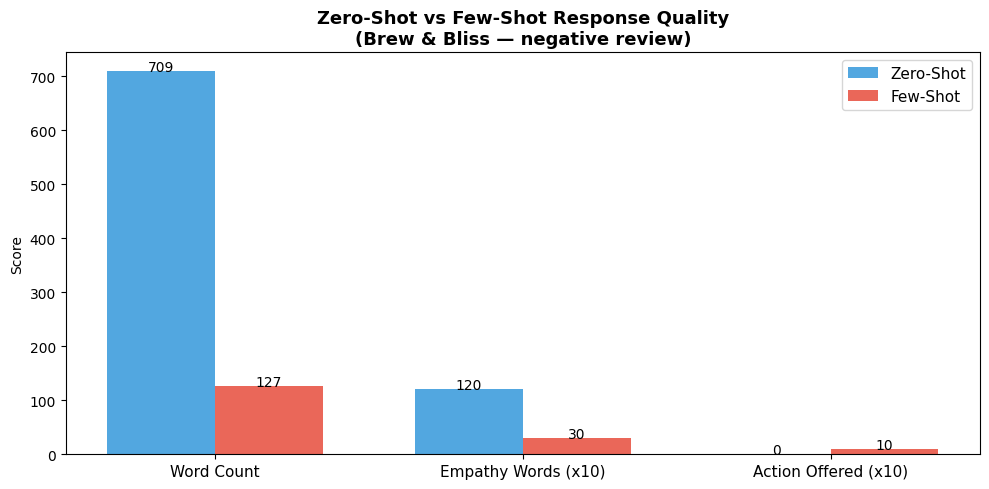

In [33]:
# ── 3d. Zero-Shot vs Few-Shot response comparison (same negative review) ─
zs_resp_prompt = PromptTemplate(
    input_variables=["review"],
    template=(
        "Write a professional management response to this coffee shop review:\n\n"
        "Review: {review}\n\nResponse:"
    )
)
zs_resp_chain = LLMChain(llm=llm, prompt=zs_resp_prompt)

target = reviews[1]   # "Waited 20 minutes..."
zs_text = zs_resp_chain.invoke({"review": target})["text"].strip()
fs_text = fewshot_chain.invoke({"review": target})["text"].strip()

print("Target review:", target)
print("\n--- ZERO-SHOT ---")
print(zs_text)
print("\n--- FEW-SHOT ---")
print(fs_text)

# ── Metric comparison chart ──────────────────────────────────────────────
def count_words(t):  return len(t.split())
def count_empathy(t): return sum(t.lower().count(w) for w in ["sorry","apologise","apologize","regret","sincerely","understand"])
def count_action(t):  return sum(t.lower().count(w) for w in ["complimentary","refund","free drink","make it right","discount"])

metrics = ["Word Count", "Empathy Words (x10)", "Action Offered (x10)"]
zs_scores = [count_words(zs_text), count_empathy(zs_text)*10, count_action(zs_text)*10]
fs_scores = [count_words(fs_text), count_empathy(fs_text)*10, count_action(fs_text)*10]

x, w = np.arange(len(metrics)), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, zs_scores, w, label="Zero-Shot", color="#3498db", alpha=0.85)
b2 = ax.bar(x + w/2, fs_scores, w, label="Few-Shot",  color="#e74c3c", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_title("Zero-Shot vs Few-Shot Response Quality\n(Brew & Bliss — negative review)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.set_ylabel("Score")
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
            str(int(b.get_height())), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("zeroshot_vs_fewshot.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 4. Chain of Thought (CoT) Prompting

**What is it?**  
Chain of Thought prompting encourages the model to **show its reasoning step-by-step** before giving a final answer. Rather than jumping to a conclusion, the model "thinks out loud", which dramatically improves accuracy on tasks that require multi-step logic.

**Key phrases that trigger CoT behaviour**
- *"Let's think step by step"*  
- *"Explain your reasoning"*  
- Numbered steps in the prompt itself (which we use here)

**Use-case here**  
A negative review arrives. Should management offer compensation, and at what level? We walk the LLM through six explicit reasoning steps to reach a transparent, defensible decision — instead of letting it guess in one shot.


In [34]:
# ── 4a. Chain of Thought prompt ─────────────────────────────────────────
cot_prompt = PromptTemplate(
    input_variables=["review"],
    template="""
You are the manager of Brew & Bliss Coffee Shop.
A customer left the review below. Decide whether to offer compensation.

Customer Review: {review}

Work through the decision step by step:

Step 1 — Identify issues: What specific problems did the customer mention?
Step 2 — Assess severity: Rate each issue 1-5 and explain why.
Step 3 — Evaluate impact: How badly was the overall experience affected?
Step 4 — Determine accountability: Which issues are the shop's fault?
Step 5 — Compensation decision:
          (A) No compensation  (B) Apology + 10% discount
          (C) Free drink       (D) Full refund + free drink
Step 6 — Draft a 2-sentence professional response.

Final Answer:
"""
)

cot_chain = LLMChain(llm=llm, prompt=cot_prompt)

# ── 4b. Run CoT on the negative review ──────────────────────────────────
target_review = reviews[1]   # "Waited 20 minutes..."
result = cot_chain.invoke({"review": target_review})
print("Review:", target_review)
print("="*60)
print(result["text"])


Review: Waited 20 minutes for my order. The latte was lukewarm and overpriced for the quality. Very disappointing.
Okay, let’s break down this customer review and decide on a compensation strategy for Brew & Bliss.

**Step 1 — Identify Issues:**

*   **Long Wait Time (20 minutes):** The customer waited an excessive amount of time for their order.
*   **Lukewarm Latte:** The temperature of the drink was unacceptable.
*   **Overpriced:** The customer felt the price didn't reflect the quality of the product.
*   **Overall Disappointment:** The customer expressed a general feeling of dissatisfaction with the experience.


**Step 2 — Assess Severity:**

*   **Long Wait Time (20 minutes):** 4/5 – This is a significant issue. 20 minutes is far longer than acceptable for a coffee order, especially during typical service times. It reflects poor operational efficiency and customer service.
*   **Lukewarm Latte:** 3/5 – Lukewarm is a common issue, but still unacceptable for a coffee shop. It impa

Direct vs CoT comparison across two reviews

Review: Waited 20 minutes for my order. The latte was lukewarm and overpr...
  Direct Answer : (D)
  CoT Decision  : **Final Answer: (B)**

Review: Nice ambiance but the WiFi was slow. The pastries were fresh and ...
  Direct Answer : (B)
  CoT Decision  : "Dear [Customer Name], we sincerely apologize that the WiFi experience during your visit fell short of our standards. We appreciate your feedback and would like to offer you a 10% discount on your next purchase to show our appreciation for your patronage."


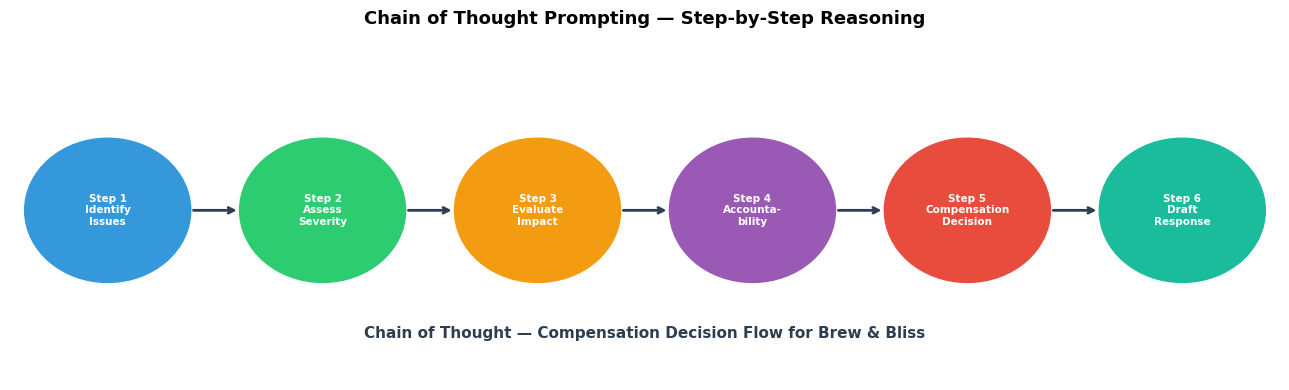

In [35]:
# ── 4c. Compare Direct Answer vs Chain of Thought ───────────────────────
direct_prompt = PromptTemplate(
    input_variables=["review"],
    template=(
        "You are the manager of Brew & Bliss Coffee Shop.\n"
        "Should you offer compensation? Answer ONLY with (A), (B), (C), or (D).\n"
        "  (A) No compensation  (B) 10% discount\n"
        "  (C) Free drink       (D) Full refund + free drink\n\n"
        "Review: {review}\nAnswer:"
    )
)
direct_chain = LLMChain(llm=llm, prompt=direct_prompt)

print("Direct vs CoT comparison across two reviews\n" + "="*60)
for review in [reviews[1], reviews[2]]:
    d = direct_chain.invoke({"review": review})["text"].strip()
    c = cot_chain.invoke({"review": review})["text"].strip()
    last_line = [l for l in c.split("\n") if l.strip()][-1]   # final decision line
    print(f"\nReview: {review[:65]}...")
    print(f"  Direct Answer : {d}")
    print(f"  CoT Decision  : {last_line}")

# ── 4d. CoT reasoning flow diagram ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis("off")
ax.set_xlim(0, 13); ax.set_ylim(0, 4)

steps = [
    ("Step 1\nIdentify\nIssues",       "#3498db"),
    ("Step 2\nAssess\nSeverity",       "#2ecc71"),
    ("Step 3\nEvaluate\nImpact",       "#f39c12"),
    ("Step 4\nAccounta-\nbility",      "#9b59b6"),
    ("Step 5\nCompensation\nDecision", "#e74c3c"),
    ("Step 6\nDraft\nResponse",        "#1abc9c"),
]
xs = np.linspace(1.0, 12.0, len(steps))
for i, ((label, color), x) in enumerate(zip(steps, xs)):
    c = plt.Circle((x, 2.0), 0.85, color=color, zorder=3)
    ax.add_patch(c)
    ax.text(x, 2.0, label, ha="center", va="center",
            fontsize=7.5, fontweight="bold", color="white", zorder=4)
    if i < len(steps) - 1:
        ax.annotate("", xy=(xs[i+1]-0.85, 2.0), xytext=(x+0.85, 2.0),
                    arrowprops=dict(arrowstyle="->", color="#2c3e50", lw=2), zorder=2)

ax.text(6.5, 0.5,
        "Chain of Thought — Compensation Decision Flow for Brew & Bliss",
        ha="center", fontsize=11, fontweight="bold", color="#2c3e50")
ax.set_title("Chain of Thought Prompting — Step-by-Step Reasoning",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("chain_of_thought.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 5. Tree of Thoughts (ToT) Prompting

**What is it?**  
Tree of Thoughts extends Chain of Thought by exploring **multiple reasoning branches in parallel** — like a decision tree. At each node the model generates several candidate thoughts, evaluates (scores) each one, prunes the weak branches, and develops only the most promising path further.

**Three-phase process**
1. **Generate** — produce N distinct strategic ideas (branches)  
2. **Evaluate** — score each branch on feasibility, customer impact, and ROI  
3. **Develop** — build a detailed action plan from the highest-scoring branch

**Use-case here**  
Given a summary of all five customer reviews, we brainstorm three improvement strategies for Brew & Bliss, score them, and develop the winner into a 30-day action plan.


In [36]:
# ── 5a. Phase 1 — Generate thought branches ────────────────────────────
generate_prompt = PromptTemplate(
    input_variables=["problem", "branch_number"],
    template="""
You are a business consultant for Brew & Bliss Coffee Shop.

Problem summary: {problem}

Propose Strategic Approach #{branch_number}.
Focus on a DIFFERENT aspect from other approaches.
Be specific and realistic. Keep it to 2-3 sentences.

Approach #{branch_number}:
"""
)

# ── 5b. Phase 2 — Evaluate each branch ─────────────────────────────────
evaluate_prompt = PromptTemplate(
    input_variables=["problem", "approach"],
    template="""
Evaluate this business strategy for Brew & Bliss Coffee Shop.

Problem: {problem}
Approach: {approach}

Score each criterion 1-10:
  Feasibility (ease of implementation): [X]/10
  Customer Impact (experience improvement): [X]/10
  ROI (return on investment): [X]/10

Total Score: [X]/30
Verdict: PROMISING / AVERAGE / WEAK

Evaluation:
"""
)

# ── 5c. Phase 3 — Develop the winning branch ───────────────────────────
develop_prompt = PromptTemplate(
    input_variables=["problem", "best_approach"],
    template="""
You are the manager of Brew & Bliss Coffee Shop.

Problem: {problem}
Selected Strategy: {best_approach}

Create a detailed 30-day implementation plan:
  Week 1: [immediate actions]
  Week 2: [implementation steps]
  Week 3: [testing & staff feedback]
  Week 4: [review & optimise]

Also list 3 success metrics to track progress.

Action Plan:
"""
)

gen_chain  = LLMChain(llm=llm, prompt=generate_prompt)
eval_chain = LLMChain(llm=llm, prompt=evaluate_prompt)
dev_chain  = LLMChain(llm=llm, prompt=develop_prompt)

problem = (
    "Brew & Bliss Coffee Shop has issues with: "
    "(1) 20-min wait times, (2) lukewarm drinks, "
    "(3) WiFi speed, (4) overpricing perception. "
    "Strengths: excellent coffee quality, friendly staff, fresh pastries."
)

print("Tree of Thoughts — Brew & Bliss Improvement Strategy\n" + "="*60)

# Phase 1 — generate branches
branches = []
for i in range(1, 4):
    b = gen_chain.invoke({"problem": problem, "branch_number": str(i)})["text"].strip()
    branches.append(b)
    print(f"\nBranch {i}:\n{b[:180]}...")

# Phase 2 — evaluate
scores = []
evals  = []
print("\n" + "="*60)
print("Evaluating branches...")
for i, branch in enumerate(branches):
    ev = eval_chain.invoke({"problem": problem, "approach": branch})["text"].strip()
    evals.append(ev)
    m = re.search(r"Total Score:\s*(\d+)/30", ev)
    score = int(m.group(1)) if m else 15
    scores.append(score)
    print(f"Branch {i+1} → Score: {score}/30")

# Phase 3 — develop the winner
best_idx   = scores.index(max(scores))
best_branch = branches[best_idx]
print(f"\nBest Branch: {best_idx+1}  (Score: {max(scores)}/30)")
plan = dev_chain.invoke({"problem": problem, "best_approach": best_branch})["text"]
print("\n30-Day Action Plan:\n" + plan)


Tree of Thoughts — Brew & Bliss Improvement Strategy

Branch 1:
**Approach #1: Immediate Focus on Drink Temperature & Service Efficiency**

Brew & Bliss should immediately prioritize addressing the lukewarm drink issue and associated wait times...

Branch 2:
**Strategic Approach #2: Streamlining the Order & Delivery Experience**

We will implement a mobile ordering and pick-up system with designated express lanes, coupled with a revise...

Branch 3:
**Strategic Approach #3: Optimize the Order Fulfillment Process & Temperature Control**

We’ll implement a streamlined order taking system – potentially utilizing tablets at the co...

Evaluating branches...
Branch 1 → Score: 21/30
Branch 2 → Score: 21/30
Branch 3 → Score: 21/30

Best Branch: 1  (Score: 21/30)

30-Day Action Plan:
Okay, here’s a detailed 30-day implementation plan for Brew & Bliss Coffee Shop, focusing on immediate improvements to drink temperature and service efficiency, as outlined by our chosen strategy.

**Brew & Bliss 

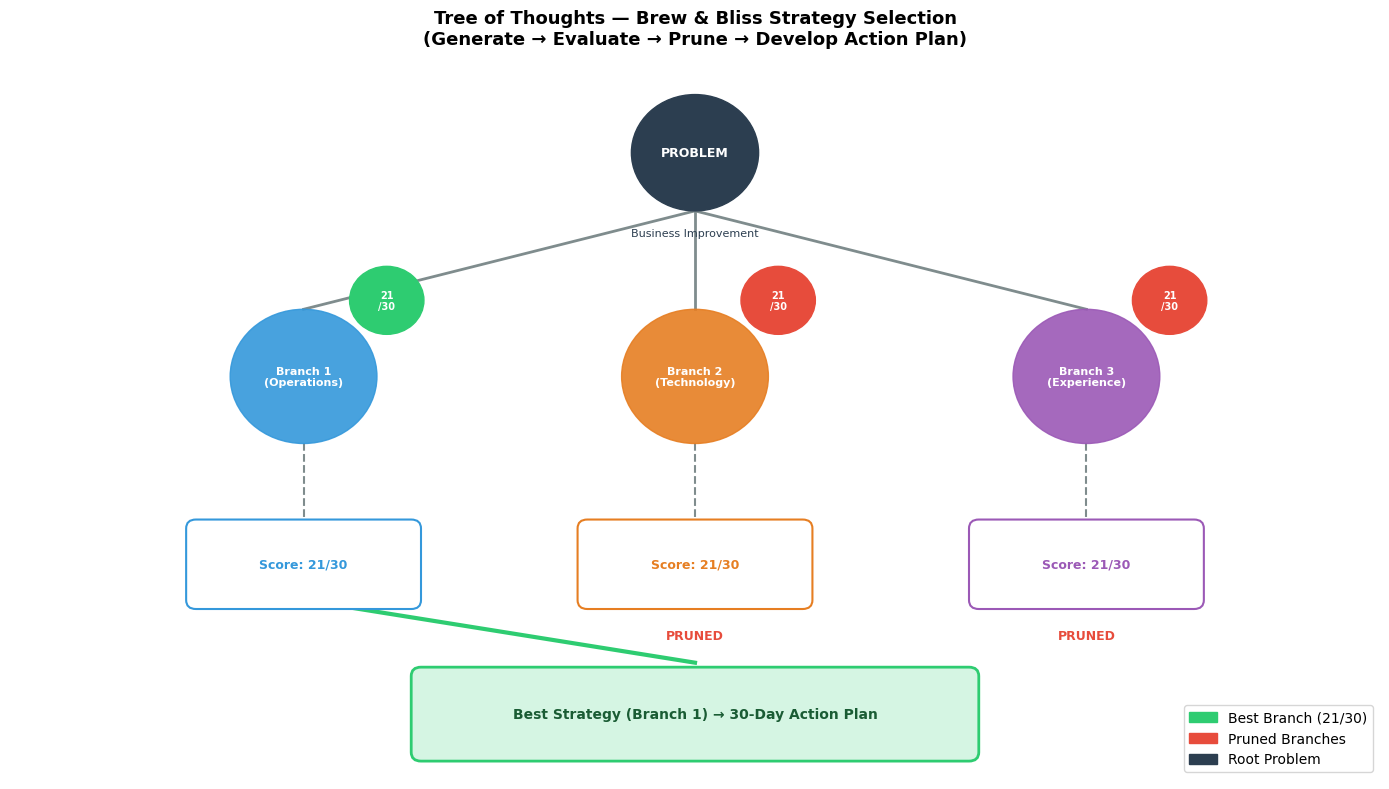

In [37]:
# ── 5d. Visualise the Tree of Thoughts ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis("off")
ax.set_xlim(0, 14); ax.set_ylim(0, 8)

# Root
root = plt.Circle((7, 7.0), 0.65, color="#2c3e50", zorder=3)
ax.add_patch(root)
ax.text(7, 7.0, "PROBLEM", ha="center", va="center",
        color="white", fontsize=9, fontweight="bold", zorder=4)
ax.text(7, 6.1, "Business Improvement", ha="center", va="center",
        fontsize=8, color="#2c3e50")

# Branch nodes
bx = [3.0, 7.0, 11.0]; by = 4.5
b_colors  = ["#3498db", "#e67e22", "#9b59b6"]
b_labels  = [f"Branch {i+1}\n({['Operations','Technology','Experience'][i]})" for i in range(3)]

for i, (x, color, label) in enumerate(zip(bx, b_colors, b_labels)):
    ax.plot([7, x], [6.35, by+0.75], color="#7f8c8d", lw=2, zorder=2)
    c = plt.Circle((x, by), 0.75, color=color, alpha=0.9, zorder=3)
    ax.add_patch(c)
    ax.text(x, by, label, ha="center", va="center",
            color="white", fontsize=8, fontweight="bold", zorder=4)
    # Score badge
    badge_color = "#2ecc71" if i == best_idx else "#e74c3c"
    badge = plt.Circle((x+0.85, by+0.85), 0.38, color=badge_color, zorder=5)
    ax.add_patch(badge)
    ax.text(x+0.85, by+0.85, f"{scores[i]}\n/30",
            ha="center", va="center", color="white", fontsize=7, fontweight="bold", zorder=6)

# Evaluation boxes
for i, x in enumerate(bx):
    ax.plot([x, x], [by-0.75, 2.6], color="#7f8c8d", lw=1.5, linestyle="--", zorder=2)
    rect = mpatches.FancyBboxPatch((x-1.1, 2.0), 2.2, 0.8,
                                    boxstyle="round,pad=0.1",
                                    edgecolor=b_colors[i], facecolor="white",
                                    linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, 2.4, f"Score: {scores[i]}/30",
            ha="center", va="center", color=b_colors[i], fontsize=9, fontweight="bold", zorder=4)

# Best branch → Action Plan
ax.plot([bx[best_idx], 7], [2.0, 1.3], color="#2ecc71", lw=3, zorder=2)
ap_box = mpatches.FancyBboxPatch((4.2, 0.3), 5.6, 0.85,
                                  boxstyle="round,pad=0.1",
                                  edgecolor="#2ecc71", facecolor="#d5f5e3",
                                  linewidth=2, zorder=3)
ax.add_patch(ap_box)
ax.text(7, 0.73, f"Best Strategy (Branch {best_idx+1}) → 30-Day Action Plan",
        ha="center", va="center", fontsize=10, color="#1a5c34", fontweight="bold", zorder=4)

# Prune marks
for i, x in enumerate(bx):
    if i != best_idx:
        ax.text(x, 1.6, "PRUNED", ha="center", va="center",
                fontsize=9, color="#e74c3c", fontweight="bold")

legend_elements = [
    mpatches.Patch(color="#2ecc71", label=f"Best Branch ({max(scores)}/30)"),
    mpatches.Patch(color="#e74c3c", label="Pruned Branches"),
    mpatches.Patch(color="#2c3e50", label="Root Problem"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)
ax.set_title("Tree of Thoughts — Brew & Bliss Strategy Selection\n"
             "(Generate → Evaluate → Prune → Develop Action Plan)",
             fontsize=13, fontweight="bold", pad=14)
plt.tight_layout()
plt.savefig("tree_of_thoughts.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Question Answering (QA)

**What is it?**  
A Question Answering system lets users ask natural-language questions over a **specific knowledge base** (documents, reviews, manuals, etc.). The LLM answers *only* from the provided context, which dramatically reduces hallucination and keeps answers grounded in real data.

**LangChain building blocks used**
- `Document` — wraps raw text with optional metadata  
- `load_qa_chain` with `chain_type="stuff"` — concatenates all documents into one prompt and asks the LLM to answer from them  
- A simple `PromptTemplate` QA wrapper for transparency

**Use-case here**  
We build a knowledge base from the five customer reviews plus three Brew & Bliss info pages, then ask management-level questions about the shop's reputation and priorities.


In [38]:
# ── 6a. Build the knowledge base ────────────────────────────────────────
from langchain.chains.question_answering import load_qa_chain
from langchain.schema import Document

# Five customer reviews
review_docs = [
    Document(
        page_content=review,
        metadata={"source": f"customer_review_{i+1}"}
    )
    for i, review in enumerate(reviews)
]

# Additional shop information
info_docs = [
    Document(
        page_content=(
            "Brew & Bliss Coffee Shop is located in downtown. "
            "It offers specialty coffees, seasonal blends, fresh pastries, "
            "and a cosy workspace with WiFi."
        ),
        metadata={"source": "about_page"}
    ),
    Document(
        page_content=(
            "Brew & Bliss hours: Mon-Fri 7 am-8 pm, Sat-Sun 8 am-9 pm. "
            "Free WiFi available. Average coffee price: $5-8."
        ),
        metadata={"source": "info_page"}
    ),
    Document(
        page_content=(
            "Baristas at Brew & Bliss are trained in specialty coffee. "
            "The shop sources single-origin beans and offers seasonal limited-edition blends."
        ),
        metadata={"source": "about_staff"}
    ),
]

all_docs = review_docs + info_docs

# Build the QA chain (stuff = all docs stuffed into one prompt)
qa_chain = load_qa_chain(llm, chain_type="stuff")

def ask(question):
    """Answer a question from the Brew & Bliss knowledge base."""
    return qa_chain.invoke({"input_documents": all_docs, "question": question})["output_text"]

print("QA system ready!")
print(f"Knowledge base: {len(all_docs)} documents ({len(review_docs)} reviews + {len(info_docs)} info pages)")


ModuleNotFoundError: No module named 'langchain.chains'

In [ ]:
# ── 6b. Ask management-level questions ──────────────────────────────────
questions = [
    "What are the most common complaints from customers?",
    "What do customers love most about Brew & Bliss?",
    "What are the opening hours and average drink prices?",
    "Which area needs the most urgent improvement: speed, quality, or atmosphere?",
    "Would you recommend Brew & Bliss to a friend based on these reviews? Why?",
]

qa_results = []
print("Brew & Bliss — Q&A System\n" + "="*60)
for q in questions:
    a = ask(q)
    qa_results.append((q, a))
    print(f"\nQ: {q}")
    print(f"A: {a.strip()}")
    print("-"*60)


In [ ]:
# ── 6c. Insights dashboard ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Brew & Bliss Coffee Shop — Customer Insights Dashboard\n"
    "(derived from QA over customer reviews)",
    fontsize=14, fontweight="bold"
)

# 1. Sentiment pie
ax1 = axes[0, 0]
sd = {"Positive": 2, "Neutral": 1, "Negative": 2}
ax1.pie(sd.values(), labels=sd.keys(),
        colors=["#2ecc71", "#f39c12", "#e74c3c"],
        autopct="%1.0f%%", startangle=90, textprops={"fontsize": 11})
ax1.set_title("Review Sentiment Split", fontsize=12, fontweight="bold")

# 2. Issue frequency
ax2 = axes[0, 1]
issues  = {"Wait Time": 2, "Drink Temp": 2, "Pricing": 1, "WiFi": 1, "Rude Staff": 1}
i_colors = ["#e74c3c","#e74c3c","#e67e22","#e67e22","#c0392b"]
b2 = ax2.bar(issues.keys(), issues.values(), color=i_colors, edgecolor="black", linewidth=0.5)
ax2.set_title("Issue Frequency in Reviews", fontsize=12, fontweight="bold")
ax2.set_ylabel("Mentions"); ax2.tick_params(axis="x", rotation=15)
for bar, v in zip(b2, issues.values()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(v), ha="center", fontsize=10, fontweight="bold")

# 3. Positive mentions
ax3 = axes[1, 0]
pos = {"Coffee Quality": 3, "Staff Friendliness": 2, "Fresh Pastries": 1,
       "Ambiance": 1, "Seasonal Blends": 1}
b3 = ax3.barh(list(pos.keys()), list(pos.values()),
              color="#2ecc71", edgecolor="black", linewidth=0.5)
ax3.set_title("Positive Aspects Mentioned", fontsize=12, fontweight="bold")
ax3.set_xlabel("Mentions")
for bar, v in zip(b3, pos.values()):
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(v), va="center", fontsize=10, fontweight="bold")

# 4. Improvement priority
ax4 = axes[1, 1]
prio = {"Wait Time": 9, "Drink Temp": 8, "Price/Value": 5, "WiFi": 4, "Ambiance": 2}
p_colors = ["#e74c3c" if v >= 7 else "#f39c12" if v >= 5 else "#2ecc71"
            for v in prio.values()]
b4 = ax4.bar(prio.keys(), prio.values(), color=p_colors, edgecolor="black", linewidth=0.5)
ax4.set_title("Improvement Priority Score\n(Higher = More Urgent)", fontsize=12, fontweight="bold")
ax4.set_ylabel("Priority Score")
ax4.tick_params(axis="x", rotation=15)
ax4.axhline(7, color="red", linestyle="--", alpha=0.5, label="High Priority (≥7)")
ax4.legend()
for bar, v in zip(b4, prio.values()):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(v), ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("qa_insights_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Summary

### Technique Comparison

| # | Technique | Best For | Examples Needed | Cost |
|---|-----------|----------|-----------------|------|
| 1 | **Basic Prompting** | Simple structured extraction | 0 | Low |
| 2 | **Zero-Shot** | Classification, labelling | 0 | Low |
| 3 | **Few-Shot** | Consistent tone & format | 2–5 | Low |
| 4 | **Chain of Thought** | Multi-step decisions | 0–few | Medium |
| 5 | **Tree of Thoughts** | Complex strategy exploration | 0 | High |
| 6 | **Question Answering** | Domain-specific Q&A | Docs | Medium |

### Key Takeaways
- Use **Basic / Zero-Shot** for quick, well-defined tasks.
- Use **Few-Shot** when the output format must be exact and consistent.
- Use **Chain of Thought** when the task requires auditable, step-by-step logic.
- Use **Tree of Thoughts** when there are multiple valid solution paths to explore.
- Use **Question Answering** to ground the LLM in your own data and prevent hallucination.

> All six techniques were demonstrated on the same Brew & Bliss Coffee Shop dataset,
> making it easy to see how each changes the depth, format, and reliability of the output.


In [ ]:
# Final comparison radar / bar chart across all 6 techniques
techniques = [
    "Basic\nPrompting", "Zero-Shot\nPrompting", "Few-Shot\nPrompting",
    "Chain of\nThought", "Tree of\nThoughts", "Question\nAnswering"
]
setup_complexity = [1, 1, 2, 2, 4, 3]
output_reliability = [3, 3, 4, 4, 5, 5]
api_cost          = [1, 1, 2, 3, 5, 3]
accuracy          = [3, 3, 4, 4, 5, 5]

x, w = np.arange(len(techniques)), 0.2
fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - 1.5*w, setup_complexity,  w, label="Setup Complexity",  color="#e74c3c", alpha=0.85)
b2 = ax.bar(x - 0.5*w, output_reliability, w, label="Output Reliability", color="#2ecc71", alpha=0.85)
b3 = ax.bar(x + 0.5*w, api_cost,           w, label="API Cost",           color="#e67e22", alpha=0.85)
b4 = ax.bar(x + 1.5*w, accuracy,            w, label="Accuracy",           color="#3498db", alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(techniques, fontsize=11)
ax.set_ylim(0, 6.5)
ax.set_ylabel("Score (1-5)", fontsize=12)
ax.set_title("Prompt Engineering Techniques — Comparison Overview\n"
             "(Brew & Bliss Coffee Shop use case)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.axhline(3, color="grey", linestyle="--", alpha=0.3)

for bars in [b1, b2, b3, b4]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
                str(int(bar.get_height())), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("techniques_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Training notebook complete!")
